In [39]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
data_set = pd.read_csv(r"D:\VS Code Files\New folder\5. Neural Network - Heart Disease Detection\heart.csv")

In [24]:
data_set.head(20)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


In [25]:
data_set.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [26]:
data_set.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [27]:
data_set.nunique()

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64

We can see that most of the table columns are in good shape but there are few columns where there is a little ambiguity on OHE techniques having more tha 2 categories like: cp, restecg, slope, ca, thal

In [28]:
# Setting dummy variables for the required columns:
data_set = pd.get_dummies(data_set, columns = ['cp','restecg','slope','thal'], drop_first= True)

In [29]:
data_set

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,63,1,145,233,1,150,0,2.3,0,1,False,False,True,False,False,False,False,True,False,False
1,37,1,130,250,0,187,0,3.5,0,1,False,True,False,True,False,False,False,False,True,False
2,41,0,130,204,0,172,0,1.4,0,1,True,False,False,False,False,False,True,False,True,False
3,56,1,120,236,0,178,0,0.8,0,1,True,False,False,True,False,False,True,False,True,False
4,57,0,120,354,0,163,1,0.6,0,1,False,False,False,True,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,140,241,0,123,1,0.2,0,0,False,False,False,True,False,True,False,False,False,True
299,45,1,110,264,0,132,0,1.2,0,0,False,False,True,True,False,True,False,False,False,True
300,68,1,144,193,1,141,0,3.4,2,0,False,False,False,True,False,True,False,False,False,True
301,57,1,130,131,0,115,1,1.2,1,0,False,False,False,True,False,True,False,False,False,True


The data is preety much cleaned up for the training part

TRAIN AND SPLIT:

In [30]:
# Creating dependent and independent variables:
X = data_set.drop(columns = ['target'])
y = data_set['target']

In [31]:
# Train and Test:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [32]:
# Standardizing X:
scaler = StandardScaler()

In [33]:
# Model sirf Training data ka mean/std 'fit' karega, aur usko transform karega
X_train_scaled = scaler.fit_transform(X_train)

# Test data par hum sirf 'transform' lagate hain (dobara fit NAHI karte)
X_test_scaled = scaler.transform(X_test)        # Only 'transform()' in order to avoid Data Leakage

TRAINING THE MODEL:

In [34]:
# 1. Target variable: y (0 aur 1) ko Categorical (2 columns) mein badalna
# Yeh 'categorical_crossentropy' loss function ki requirement hoti hai
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)


In [35]:
# OHE ke baad naye columns ki ginti nikalna
n_features = X_train_scaled.shape[1]
print(f"Total input features after OHE: {n_features}")

Total input features after OHE: 19


In [36]:
# 2. Assignment wala model banana
def create_model():
    model = Sequential()
    
    # Hidden Layer (input_dim ab dynamic hai)
    model.add(Dense(16, input_dim=n_features, kernel_initializer='normal', 
                    kernel_regularizer=regularizers.l2(0.001), activation='sigmoid'))
    
    # Output Layer (2 neurons for Healthy vs Disease)
    model.add(Dense(2, activation='softmax'))
    
    # Compile Model
    # Note: Assignment screenshot mein adam define kiya hai par use 'rmsprop' kiya hai. 
    # Hum strictly assignment ke compile code ko follow kar rahe hain.
    model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])
    return model



In [38]:
# 3. Model initialize karna
model = create_model()
print(model.summary())

# 4. Model Training (Fit)
print("\n🚀 Training starts...")
# validation_data parameter har epoch ke baad test score bhi batayega
history = model.fit(X_train_scaled, y_train_cat, 
                    epochs=50, 
                    batch_size=10, 
                    validation_data=(X_test_scaled, y_test_cat))

print("\n✅ Training Complete!")

d:\VS Code Files\New folder\5. Neural Network - Heart Disease Detection\heart_venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 354 (1.38 KB)

 Trainable params: 354 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

None

🚀 Training starts...
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7975 - loss: 0.6210 - val_accuracy: 0.8852 - val_loss: 0.5594
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8099 - loss: 0.5609 - val_accuracy: 0.9016 - val_loss: 0.5042
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8182 - loss: 0.5180 - val_accuracy: 0.8852 - val_loss: 0.4604
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8264 - loss: 0.4849 - val_accuracy: 0.8852 - val_loss: 0.4263
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8182 - loss: 0.4600 - val_accuracy: 0.8852 - val_loss: 0.4055
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8264 - loss: 0.4432 - val_accuracy: 0.8852 - val_loss: 0.3867
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8306 - loss: 0.4288 - val_accuracy: 0.8852 - val_loss: 0.3721
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8347 - loss: 0.4175 - val_a

Model is now trained, lets look go with the evaluation part

In [40]:
# 1. Model se Test data (anjaan data) par predictions lena
# Keras yahan direct 0 ya 1 nahi dega, balki probability dega (e.g., [0.10, 0.90])
y_pred_prob = model.predict(X_test_scaled)

# 2. Probabilities ko wapas 0 aur 1 (Classes) mein badalna
# np.argmax us column ko chunega jiski probability zyada hai
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_test_classes = np.argmax(y_test_cat, axis=1) # True answers

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


Confusion Matrix:
 [[27  2]
 [ 5 27]]


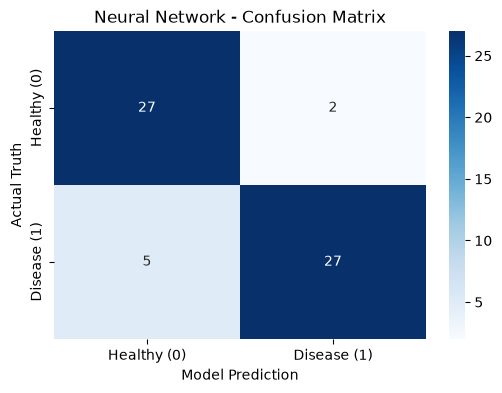


CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Healthy (0)       0.84      0.93      0.89        29
 Disease (1)       0.93      0.84      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [41]:
# 3. Confusion Matrix print karna aur uska Graph banana
cm = confusion_matrix(y_test_classes, y_pred_classes)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy (0)', 'Disease (1)'], 
            yticklabels=['Healthy (0)', 'Disease (1)'])
plt.title('Neural Network - Confusion Matrix')
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.show()

# 4. Saare Various Metrics (Precision, Recall, F1-Score) ek sath dekhna
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test_classes, y_pred_classes, target_names=['Healthy (0)', 'Disease (1)']))

-------------------------------------------------------------------------------------------------------------------------------------------

**Although this much accuracy is good for such model but to increase the accuracy, we can have following methods:**


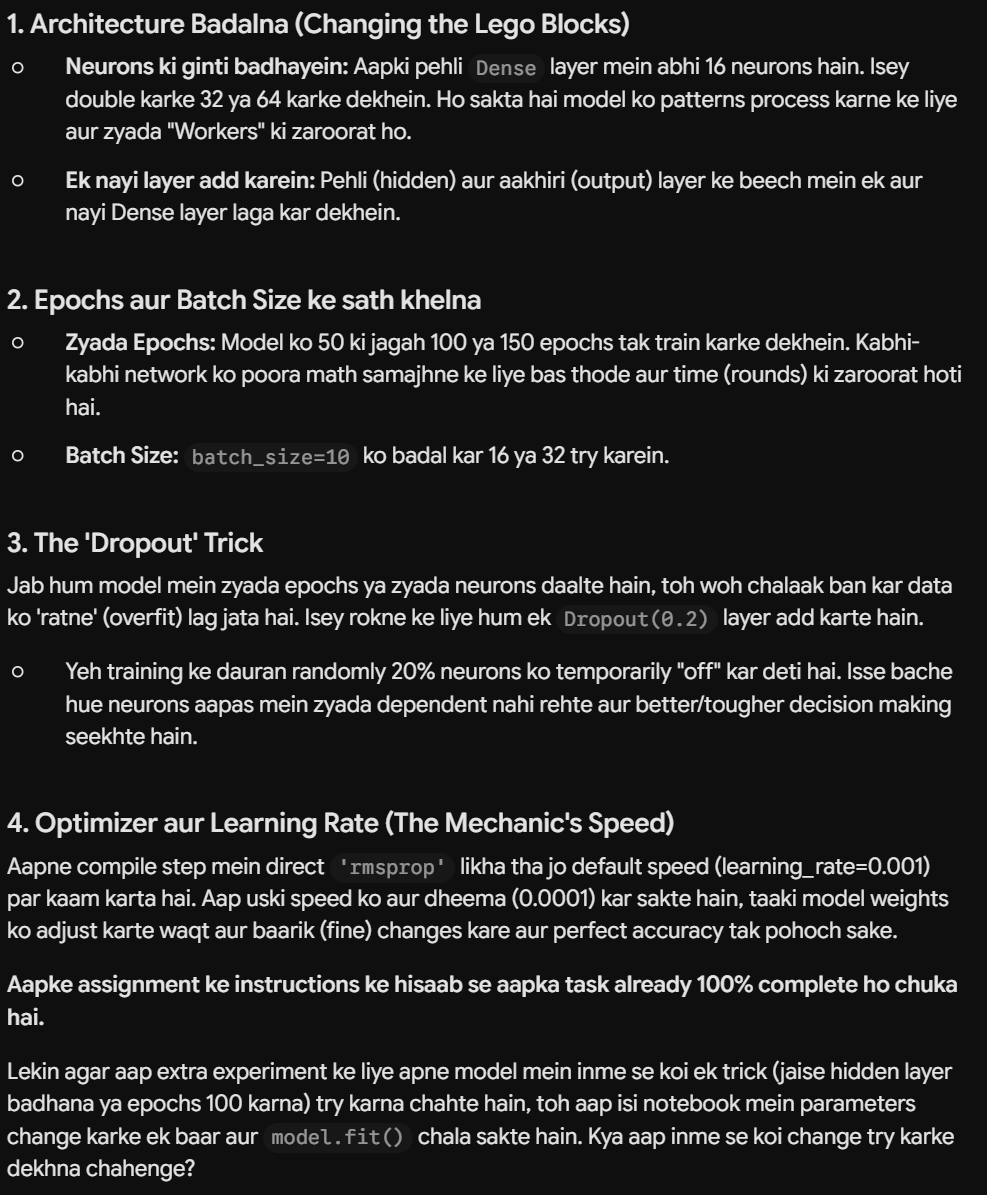